In [123]:
import seaborn as sns;
import matplotlib.pyplot as plt;
import numpy as np;
import pandas as pd;
from sklearn.model_selection import train_test_split

In [124]:
df = pd.read_csv('dataset/house_prices_dataset.csv')
df

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903
...,...,...,...,...,...
9995,2650.551032,7,9,18.126034,431344.267823
9996,1000.827516,2,53,24.479692,6650.271134
9997,1647.341638,5,80,2.189312,233698.384301
9998,2247.882787,6,73,27.931014,280766.827379


**No empty values**:

In [125]:
df.isna().sum()

square_feet             0
num_rooms               0
age                     0
distance_to_city(km)    0
price                   0
dtype: int64

In [126]:
df.drop_duplicates()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903
...,...,...,...,...,...
9995,2650.551032,7,9,18.126034,431344.267823
9996,1000.827516,2,53,24.479692,6650.271134
9997,1647.341638,5,80,2.189312,233698.384301
9998,2247.882787,6,73,27.931014,280766.827379


In [127]:
df[df['price']<=0]['price'].count()

np.int64(38)

In [128]:
df['price'] = df['price'].where(df['price'] > 0, -df['price'])


In [129]:
df["square_meters"] = df["square_feet"] * 0.092903
df = df.drop(columns=["square_feet"])
df = df[["square_meters", "num_rooms","age","distance_to_city(km)","price" ]]
df.to_csv("dataset/house_prices2.csv", index=False)

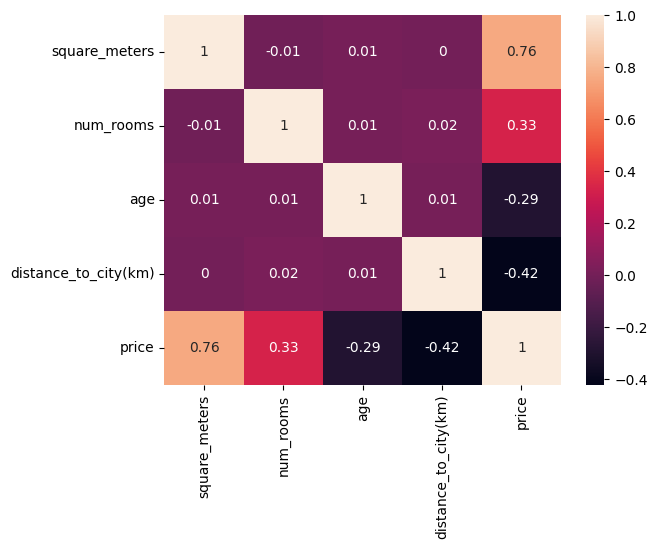

In [130]:
mat = df.corr().round(2)
sns.heatmap(data=mat, annot=True)
plt.show()

as we can see , there is a weak correlation between num_rooms and the price, which implies that num_rooms is not needed

In [131]:
df = df.drop(columns=["num_rooms"])

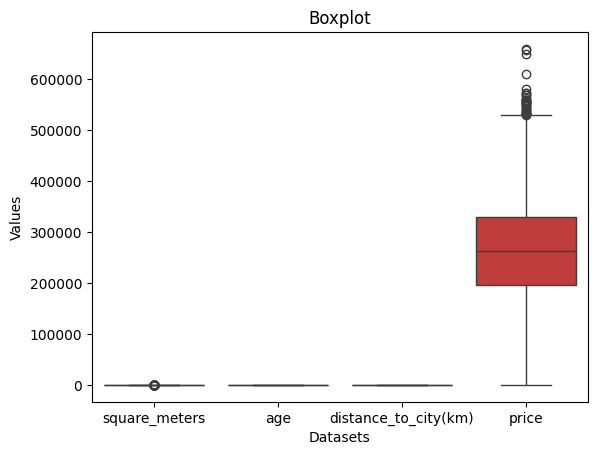

In [132]:
#outliers:
data = [df["square_meters"],df["age"] , df["distance_to_city(km)"],df["price"]]
# Create a boxplot
sns.boxplot(data)
# Add labels and title
plt.xlabel('Datasets')
plt.ylabel('Values')
plt.title('Boxplot')

plt.show()





after a couple of tests, deleting the outliers will make the model worse

In [133]:
# Q1 = df['price'].quantile(0.25)
# Q3 = df['price'].quantile(0.75)
# IQR = Q3 - Q1

# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

# df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
# print("Outliers:")
# print(df)

In [134]:
y = df['price'].round(2)


x = df.drop(columns=["price"]).round(2)

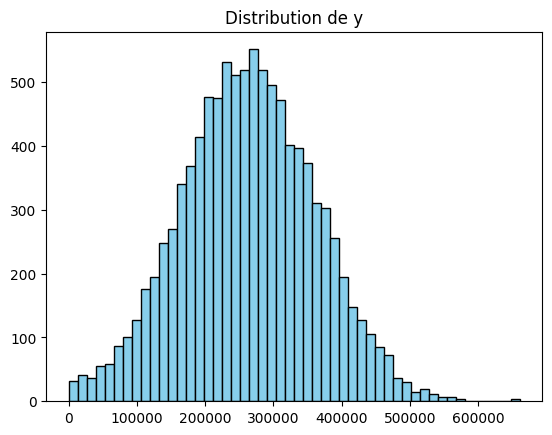

In [135]:
import matplotlib.pyplot as plt

plt.hist(y, bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution de y")
plt.show()

In [136]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, 
    test_size=0.2, 
    random_state=42
)

In [137]:
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(8000, 3) (2000, 3)
(8000,) (2000,)


In [138]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


model = LinearRegression()
model.fit(x_train, y_train)


print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [ 1598.16425235  -991.12630389 -4912.35284648]
Intercept: 91183.9953966783


In [139]:
y_pred = model.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)
rmse = np.sqrt(mse)
print("RMSE:", rmse)
print("R²:", r2_score(y_test, y_pred))


MSE: 1497528955.7410429
RMSE: 38697.919268883736
R²: 0.8441904298883852


In [140]:
biais = (y_pred - y_test)
print("Biais moyen:", biais)

Biais moyen: 6252    16902.499315
4684    -2729.536479
1731   -30255.761510
4742   -30311.470209
4521   -20345.232438
            ...     
6412    29820.320716
8285    41478.730600
7853    25957.330752
1095     -689.453895
6929    12929.983995
Name: price, Length: 2000, dtype: float64


In [141]:
#     248.15   53                 23.42

sample = pd.DataFrame([{
    "square_meters": 256.2,
    "age": 21,
    "distance_to_city(km)": 9.19
    }])


y_pred = model.predict(sample)
print("Predicted price:", y_pred[0])


Predicted price: 434675.5018089741


In [142]:
print("x_test (milieu):")
print(x_test[0:10])

print("\ny_test (milieu):")
print(y_test[0:10])

x_test (milieu):
      square_meters  age  distance_to_city(km)
6252         308.34   96                 24.76
4684         137.63   60                  3.23
1731         169.58   76                 19.05
4742         185.88   65                 24.62
4521         235.71   81                  4.09
6340         142.80   32                 26.27
576          196.75   40                 29.99
5202         192.75   67                 23.99
6363         217.54   39                 24.54
439          183.23   88                 12.59

y_test (milieu):
6252    350281.48
4684    238534.40
1731    223550.53
4742    233196.90
4521    387859.77
6340     80706.00
576     210892.53
5202    157576.72
6363    260014.39
439     203015.43
Name: price, dtype: float64


In [143]:
import joblib
joblib.dump(model, "linear_model_wout.pkl")

['linear_model_wout.pkl']

In [144]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Dataset
df = pd.read_csv("dataset/house_prices2.csv")

# Sélection des features et target
X = df[['square_meters', 'age', 'distance_to_city(km)']]
y = df['price']

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline : Polynomial features + Ridge Regression
pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)),
    ('ridge', Ridge(alpha=1.0))
])

# Entraînement
pipeline.fit(X_train, y_train)

# Prédictions
y_pred = pipeline.predict(X_test)

# Évaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")


MSE: 1497522357.8905807
RMSE: 38697.83402066039
R²: 0.8441911161346224
